## 0. 설정

In [1]:
<< mTensor`

In [2]:
$PreRead = 
  ReplaceAll[#, 
    expr_String :> StringReplace[expr,
    "TMP" -> "mTensor`Private"]] &;

## 1. Utilities

### 1.1 FreePatternQ

In [3]:
FreePatternQ /@ {a, a : True, PatternSequence[a, b_, c], _, __, ___}

{True, False, False, False, False, False}

### 1.2 PositiveIntegerQ

In [4]:
PositiveIntegerQ /@ {-1, 0, 1, some}

{False, False, True, False}

### 1.3 SymbolJoin

In [5]:
SymbolJoin[{a, b, c}]

abc

In [6]:
SymbolJoin[a, b, c]

abc

### 1.4 allQoptions

In [7]:
TMP`allQoptions[HeadQs][head, {HeadQs -> {True &, False &}}]

False

In [8]:
TMP`allQoptions[IndexQs][idx, {IndexQs -> {False &, True &}}]

False

### 1.5 forEachTerm

In [9]:
TMP`forEachTerm[c == a d + b e, actF, arg1, arg2]

actF[c, arg1, arg2] == actF[a d, arg1, arg2] + actF[b e, arg1, arg2]

### 1.6 signTerm

In [10]:
TMP`signTerm /@ {-a, b}

{-1, 1}

## 2. Indices

### 2.1 인덱스 분류

인덱스는 IndexType, Lower/Upper, IndexKind에 따라 구별된다.

인덱스에 대한 연산을 하는 함수는 옵션으로 인덱스가 만족해야 할 질의함수 리스트인 `IndexQs`를 가질 수 있다. 이 옵션을 갖는 함수는 그 질의함수들을 모두 만족하는 인덱스에 대해서만 작용한다.

In [15]:
dnIndexL = {-1, l0, la, lA, lba, lda, lha};
upIndexL = {1, u0, ua, uA, uba, uda, uha};
indexL = Flatten[{dnIndexL, upIndexL}];

#### 2.1.1 IndexType

##### 2.1.1.1 RegularIndexQ

인자가 regular 인덱스인가를 판단하는 질의함수이다. 심볼이면 RegularType이다.

In [14]:
RegularIndexQ /@ {hello, dhpark, la, lo, ua, uo}

{True, True, True, True, True, True}

##### 2.1.1.2 DummyIndexQ

인자가 프로그램이 자동적으로 생성한 dummy 인덱스인가를 판단하는 질의함수이다. 문자열이면 DummyType이다.

In [18]:
DummyIndexQ /@ {"hello", "dhpark", "l$1", "u$1"}

{True, True, True, True}

##### 2.1.1.3 ComponentIndexQ

인자가 component 인덱스인가를 판단하는 질의함수이다. ComponentType은 0을 제외한 정수이다.

In [19]:
ComponentIndexQ /@ {-1, -2, 0, 1, 2}

{True, True, False, True, True}

#### 2.1.2 Lower or Upper

##### 2.1.2.1 DnIndexQ

인자가 down (or lower) 인덱스인가를 판단하는 질의함수이다. 인덱스의 이름이 "l"(ell)로 시작하거나 음의 정수이면 down 인덱스이다.

In [20]:
Select[indexL, DnIndexQ]

{-1, l0, la, lA, lba, lda, lha}

##### 2.1.2.2 UpIndexQ

인자가 up (or upper) 인덱스인가를 판단하는 질의함수이다. 인덱스의 이름이 "u"로 시작하거나 양의 정수이면 up 인덱스이다.

In [21]:
Select[indexL, UpIndexQ]

{1, u0, ua, uA, uba, uda, uha}

#### 2.1.3 IndexKind

인덱스 계열(Kind)를 정의하거나 제거한다. Kind는 텐서에 대한 vector bundle 개념으로 사용할 수도 있지만, 일반적으로 텐서가 취할 수 있는 인덱스의 계열을 의미한다.

`Zero`와 `Latin` kind를 제외하고 최대 9개의 kind를 도입할 수 있다:

In [22]:
TMP`dummyPreListPrepared

{%, !, @, #, &, |, :, ;, ?}

##### 2.1.3.1 Zero

`Zero` 계열은 이미 정의되어 있고, 제거할 수도 없다.

In [23]:
TMP`allIndexCharacters[Zero]

{0}

In [24]:
{TMP`dummyPreCharacter[Zero], TMP`dummyState[Zero], 
 TMP`indicesNumState[Zero], TMP`indexKind[l0],
 TMP`indexKind[u0]}

{/, 1, 0, Zero, Zero}

In [25]:
RemoveKind[Zero]

`1` `2` `3` `4`: Cannot remove the Zero kind.   

`Zero` 계열의 인덱스는 `RegularType`인 경우 인덱스 이름의 두 번째 문자가 0이고, `DummyType`은 두 번째 문자가 '/'이고 유일한 정수로 끝난다.

In [26]:
TMP`indexKind /@ {l0, "l/1", u0, "u/1"}

{Zero, Zero, Zero, Zero}

In [27]:
KindIndexQ[Zero]

mTensor`Private`indexKind[#1] === Zero &

In [28]:
KindIndexQ[Zero] /@ {l0, "l/1", u0, "u/1"}

{True, True, True, True}

In [29]:
KindIndexQ[Zero][#] && DnIndexQ[#] & /@ {l0, "l/1", u0, "u/1"}

{True, True, False, False}

`Zero` 계열의 인덱스는 변경시킬 수 없다:

In [30]:
SetIndices[{}, Zero]

`1` `2` `3` `4`: Zero's indices are fixed.   

##### 2.1.3.2 Latin

`Latin` 계열은 이미 정의되어 있고, 제거할 수도 없다.

In [31]:
TMP`allIndexCharacters[Latin]

{a, b, c, d, e, f, g, h, i, j, k, l, m, n, o, p, q, r, s, t, u, v, w, x, y, z}

In [32]:
{TMP`dummyPreCharacter[Latin], TMP`dummyState[Latin], 
 TMP`indicesNumState[Latin], TMP`indexKind[la],
 TMP`indexKind[ua]}

{$, 1, 0, Latin, Latin}

In [33]:
RemoveKind[Latin]

`1` `2` `3` `4`: Cannot remove the Latin kind.   

`Latin` 계열의 인덱스는 `RegularType`인 경우 인덱스 이름의 두 번째 문자가 영문자이고, `DummyType`은 두 번째 문자가 '$'이고 유일한 정수로 끝난다.

In [34]:
TMP`indexKind /@ {la, lb, "l$1", ua, ub, "u$1"}

{Latin, Latin, Latin, Latin, Latin, Latin}

In [35]:
KindIndexQ[Latin] /@ {la, lb, "l$1", ua, ub, "u$1"}

{True, True, True, True, True, True}

In [36]:
KindIndexQ[Latin][#] && DnIndexQ[#] & /@ {la, lb, "l$1",
                                            ua, ub, "u$1"}

{True, True, True, False, False, False}

In [37]:
DefaultKind

Latin

In [38]:
{Epsilon[la, lb], Torsion[la, lb, uc]}

{Epsilon[la, lb], Torsion[la, lb, uc]}

`Latin` 계열의 인덱스를 다른 목적으로 사용하기 위해 `Latin` 계열을 무력화하려면 비어 있는 인덱스 리스트를 `SetIndices` 명령에 사용한다:

In [39]:
SetIndices[{}, Latin]

In [40]:
{TMP`allIndexCharacters[Latin], TMP`indexKind[la],
 TMP`indexKind[ua]}

{{}, mTensor`Private`errorIndex, mTensor`Private`errorIndex}

In [41]:
SetIndices[Alphabet[], Latin]  (* default *)

In [42]:
TMP`allIndexCharacters[Latin]

{a, b, c, d, e, f, g, h, i, j, k, l, m, n, o, p, q, r, s, t, u, v, w, x, y, z}

##### 2.1.3.3 Greek

새로운 인덱스 계열(Kind)를 정의하려면 `DefineKind` 명령에 인자로 사용할 인덱스 리스트와 Kind 이름을 사용한다:

`Greek` 계열은 인덱스가 그리스 문자인 경우를 위한 것이다.

In [43]:
DefineKind[Alphabet["Greek"], Greek]

In [44]:
TMP`allIndexCharacters[Greek]

{α, β, γ, δ, ε, ζ, η, θ, ι, κ, λ, μ, ν, ξ, ο, π, ρ, σ, τ, υ, φ, χ, ψ, ω}

In [45]:
{TMP`dummyPreCharacter[Greek], TMP`dummyState[Greek], 
 TMP`indicesNumState[Greek], TMP`indexKind[l\[Mu]],
 TMP`indexKind[u\[Mu]]}

{%, 1, 0, Greek, Greek}

In [46]:
TMP`indexKind /@ {l\[Alpha], l\[Mu], "l%1",
                   u\[Alpha], u\[Mu], "u%1"}

{Greek, Greek, Greek, Greek, Greek, Greek}

In [47]:
KindIndexQ[Greek] /@ {l\[Alpha], l\[Mu], "l%1",
                        u\[Alpha], u\[Mu], "u%1"}

{True, True, True, True, True, True}

In [48]:
KindIndexQ[Greek][#] && UpIndexQ[#] & /@{l\[Alpha], l\[Mu], "l%1",
                                           u\[Alpha], u\[Mu], "u%1"}

{False, False, False, True, True, True}

In [49]:
{EpsilonGreek[l\[Mu], l\[Nu]],
 TorsionGreek[l\[Mu], l\[Nu], u\[Rho]]}

{EpsilonGreek[lμ, lν], TorsionGreek[lμ, lν, uρ]}

정의된 인덱스 계열을 제거하려면 `RemoveKind` 명령을 사용한다:

In [50]:
RemoveKind[Greek]

##### 2.1.3.4 Capital

`Capital` 계열은 인덱스가 영문 대문자인 경우를 위한 것이다.

In [51]:
DefineKind[ToUpperCase /@ Alphabet[], Capital]

In [52]:
TMP`allIndexCharacters[Capital]

{A, B, C, D, E, F, G, H, I, J, K, L, M, N, O, P, Q, R, S, T, U, V, W, X, Y, Z}

In [53]:
{TMP`dummyPreCharacter[Capital], TMP`dummyState[Capital], 
 TMP`indicesNumState[Capital], TMP`indexKind[lA],
 TMP`indexKind[uA]}

{!, 1, 0, Capital, Capital}

In [54]:
TMP`indexKind /@ {lA, lO, "l!1", uA, uO, "u!1"}

{Capital, Capital, Capital, Capital, Capital, Capital}

In [55]:
KindIndexQ[Capital] /@ {lA, lO, "l!1", uA, uO, "u!1"}

{True, True, True, True, True, True}

In [56]:
KindIndexQ[Capital][#] && DnIndexQ[#] & /@ {lA, lO, "l!1",
                                               uA, uO, "u!1"}

{True, True, True, False, False, False}

In [57]:
{EpsilonCapital[lA, lB], TorsionCapital[lA, lB, uC]}

{EpsilonCapital[lA, lB], TorsionCapital[lA, lB, uC]}

In [58]:
RemoveKind[Capital]

##### 2.1.3.5 Bar

`Latin` 계열의 인덱스에 Bar 기호가 붙는 경우이다.

In [59]:
DefineKind["b" <> # & /@ Alphabet[], Bar]

In [60]:
TMP`allIndexCharacters[Bar]

{ba, bb, bc, bd, be, bf, bg, bh, bi, bj, bk, bl, bm, bn, bo, bp, bq, br, bs, bt, bu, bv, 
 
>   bw, bx, by, bz}

In [61]:
{TMP`dummyPreCharacter[Bar], TMP`dummyState[Bar], 
 TMP`indicesNumState[Bar], TMP`indexKind[lba],
 TMP`indexKind[uba]}

{@, 1, 0, Bar, Bar}

In [62]:
TMP`indexKind /@ {lba, lbb, "l@1", uba, ubb, "u@1"}

{Bar, Bar, Bar, Bar, Bar, Bar}

In [63]:
KindIndexQ[Bar] /@ {lba, lbb, "l@1", uba, ubb, "u@1"}

{True, True, True, True, True, True}

In [64]:
KindIndexQ[Bar][#] && DnIndexQ[#] & /@ {lba, lbb, "l@1",
                                           uba, ubb, "u@1"}

{True, True, True, False, False, False}

In [65]:
{EpsilonBar[lba, lbb], TorsionBar[lba, lbb, ubc]}

{EpsilonBar[lba, lbb], TorsionBar[lba, lbb, ubc]}

In [66]:
RemoveKind[Bar]

##### 2.1.3.6 BarCapital

대문자 계열의 인덱스에 `Bar` 기호가 붙는 경우이다.

In [67]:
DefineKind["b" <> # & /@ ToUpperCase /@ Alphabet[], BarCapital]

In [68]:
TMP`allIndexCharacters[BarCapital]

{bA, bB, bC, bD, bE, bF, bG, bH, bI, bJ, bK, bL, bM, bN, bO, bP, bQ, bR, bS, bT, bU, bV, 
 
>   bW, bX, bY, bZ}

In [69]:
{TMP`dummyPreCharacter[BarCapital],
 TMP`dummyState[BarCapital], 
 TMP`indicesNumState[BarCapital], TMP`indexKind[lbA],
 TMP`indexKind[ubA]}

{#, 1, 0, BarCapital, BarCapital}

In [70]:
TMP`indexKind /@ {lbA, lbB, "l#1", ubA, ubB, "u#1"}

{BarCapital, BarCapital, BarCapital, BarCapital, BarCapital, BarCapital}

In [71]:
KindIndexQ[BarCapital] /@ {lbA, lbB, "l#1", ubA, ubB, "u#1"}

{True, True, True, True, True, True}

In [72]:
KindIndexQ[BarCapital][#] && DnIndexQ[#] & /@ {lbA, lbB, "l#1",
                                                  ubA, ubB, "u#1"}

{True, True, True, False, False, False}

In [73]:
{EpsilonBarCapital[lbA, lbB], TorsionBarCapital[lbA, lbB, ubC]}

{EpsilonBarCapital[lbA, lbB], TorsionBarCapital[lbA, lbB, ubC]}

In [74]:
RemoveKind[BarCapital]

##### 2.1.3.7 Dot

Latin 계열의 인덱스에 Dot 기호가 붙는 경우이다.

In [75]:
DefineKind["d" <> # & /@ Alphabet[], Dot]

In [76]:
TMP`allIndexCharacters[Dot]

{da, db, dc, dd, de, df, dg, dh, di, dj, dk, dl, dm, dn, do, dp, dq, dr, ds, dt, du, dv, 
 
>   dw, dx, dy, dz}

In [77]:
{TMP`dummyPreCharacter[Dot], TMP`dummyState[Dot], 
 TMP`indicesNumState[Dot], TMP`indexKind[lda],
 TMP`indexKind[uda]}

{&, 1, 0, Dot, Dot}

In [78]:
TMP`indexKind /@ {lda, ldb, "l&1", uda, udb, "u&1"}

{Dot, Dot, Dot, Dot, Dot, Dot}

In [79]:
KindIndexQ[Dot] /@ {lda, ldb, "l&1", uda, udb, "u&1"}

{True, True, True, True, True, True}

In [80]:
KindIndexQ[Dot][#] && DnIndexQ[#] & /@ {lda, ldb, "l&1",
                                          uda, udb, "u&1"}

{True, True, True, False, False, False}

In [81]:
{EpsilonDot[lda, ldb], TorsionDot[lda, ldb, udc]}

{EpsilonDot[lda, ldb], TorsionDot[lda, ldb, udc]}

In [82]:
RemoveKind[Dot]

##### 2.1.3.8 DotCapital

대문자 계열의 인덱스에 `Dot` 기호가 붙는 경우이다.

In [83]:
DefineKind["d" <> # & /@ ToUpperCase /@ Alphabet[], DotCapital]

In [84]:
TMP`allIndexCharacters[DotCapital]

{dA, dB, dC, dD, dE, dF, dG, dH, dI, dJ, dK, dL, dM, dN, dO, dP, dQ, dR, dS, dT, dU, dV, 
 
>   dW, dX, dY, dZ}

In [85]:
{TMP`dummyPreCharacter[DotCapital],
 TMP`dummyState[DotCapital], 
 TMP`indicesNumState[DotCapital], TMP`indexKind[ldA],
 TMP`indexKind[udA]}

{|, 1, 0, DotCapital, DotCapital}

In [86]:
TMP`indexKind /@ {ldA, ldB, "l|1", udA, udB, "u|1"}

{DotCapital, DotCapital, DotCapital, DotCapital, DotCapital, DotCapital}

In [87]:
KindIndexQ[DotCapital] /@ {ldA, ldB, "l|1", udA, udB, "u|1"}

{True, True, True, True, True, True}

In [88]:
KindIndexQ[DotCapital][#] && DnIndexQ[#] & /@ {ldA, ldB, "l|1",
                                                  udA, udB, "u|1"}

{True, True, True, False, False, False}

In [89]:
{EpsilonDotCapital[ldA, ldB], TorsionDotCapital[ldA, ldB, udC]}

{EpsilonDotCapital[ldA, ldB], TorsionDotCapital[ldA, ldB, udC]}

In [90]:
RemoveKind[DotCapital]

##### 2.1.3.9 Hat

`Latin` 계열의 인덱스에 `Hat` 기호가 붙는 경우이다.

In [91]:
DefineKind["h" <> # & /@ Alphabet[], Hat]

In [92]:
TMP`allIndexCharacters[Hat]

{ha, hb, hc, hd, he, hf, hg, hh, hi, hj, hk, hl, hm, hn, ho, hp, hq, hr, hs, ht, hu, hv, 
 
>   hw, hx, hy, hz}

In [93]:
{TMP`dummyPreCharacter[Hat], TMP`dummyState[Hat], 
 TMP`indicesNumState[Hat], TMP`indexKind[lha],
 TMP`indexKind[uha]}

{:, 1, 0, Hat, Hat}

In [94]:
TMP`indexKind /@ {lha, lhb, "l:1", uha, uhd, "u:1"}

{Hat, Hat, Hat, Hat, Hat, Hat}

In [95]:
KindIndexQ[Hat] /@ {lha, lhb, "l:1", uha, uhd, "u:1"}

{True, True, True, True, True, True}

In [96]:
KindIndexQ[Hat][#] && DnIndexQ[#] & /@ {lha, lhb, "l:1",
                                          uha, uhd, "u:1"}

{True, True, True, False, False, False}

In [97]:
{EpsilonHat[lha, lhb], TorsionHat[lha, lhb, uhc]}

{EpsilonHat[lha, lhb], TorsionHat[lha, lhb, uhc]}

In [98]:
RemoveKind[Hat]

##### 2.1.3.10 HatGreek

`Greek` 계열의 인덱스에 `Hat` 기호가 붙는 경우이다.

In [99]:
DefineKind["h" <> # & /@ Alphabet["Greek"], HatGreek]

In [100]:
TMP`allIndexCharacters[HatGreek]

{hα, hβ, hγ, hδ, hε, hζ, hη, hθ, hι, hκ, hλ, hμ, hν, hξ, hο, hπ, hρ, hσ, hτ, hυ, hφ, hχ, 
 
>   hψ, hω}

In [101]:
{TMP`dummyPreCharacter[HatGreek], TMP`dummyState[HatGreek], 
 TMP`indicesNumState[HatGreek], TMP`indexKind[lh\[Mu]], 
 TMP`indexKind[uh\[Mu]]}

{;, 1, 0, HatGreek, HatGreek}

In [102]:
TMP`indexKind /@ {lh\[Mu], lh\[Nu], "l;1",
                   uh\[Rho], uh\[Sigma], "u;1"}

{HatGreek, HatGreek, HatGreek, HatGreek, HatGreek, HatGreek}

In [103]:
KindIndexQ[HatGreek] /@ {lh\[Mu], lh\[Nu], "l;1",
                           uh\[Rho], uh\[Sigma], "u;1"}

{True, True, True, True, True, True}

In [104]:
KindIndexQ[HatGreek][#]&&DnIndexQ[#]& /@{lh\[Mu], lh\[Nu], "l;1",
                                        uh\[Rho], uh\[Sigma], "u;1"}

{True, True, True, False, False, False}

In [105]:
{EpsilonHatGreek[lh\[Mu], lh\[Nu]],
 TorsionHatGreek[lh\[Mu], lh\[Nu], uh\[Rho]]}

{EpsilonHatGreek[lhμ, lhν], TorsionHatGreek[lhμ, lhν, uhρ]}

In [106]:
RemoveKind[HatGreek]

##### 2.1.3.11 HatZero

`Zero` 계열의 인덱스에 `Hat` 기호가 붙는 경우이다.

In [107]:
DefineKind[{"h0"}, HatZero]

In [108]:
TMP`allIndexCharacters[HatZero]

{h0}

In [109]:
{TMP`dummyPreCharacter[HatZero], TMP`dummyState[HatZero], 
 TMP`indicesNumState[HatZero], TMP`indexKind[lh0],
 TMP`indexKind[uh0]}

{?, 1, 0, HatZero, HatZero}

In [110]:
TMP`indexKind /@ {lh0, "l?1", uh0, "u?1"}

{HatZero, HatZero, HatZero, HatZero}

In [111]:
KindIndexQ[HatZero] /@ {lh0, "l?1", uh0, "u?1"}

{True, True, True, True}

In [112]:
KindIndexQ[HatZero][#] && DnIndexQ[#] & /@ {lh0, "l?1",
                                               uh0, "u?1"}

{True, True, False, False}

In [113]:
RemoveKind[HatZero]

##### 2.1.3.12 checkIndexKind

In [114]:
TMP`checkIndexKind /@ {Zero, Latin, Greek, Capital,
                         Bar, Dot, Hat, None}

{True, True, False, False, False, False, False, False}

In [115]:
TMP`checkIndexKind[None, True]

`1` is not a valid `2`.: None is not a valid indexKind.

False

### 2.2 AddIndices

#### 2.2.1 ShowIndices

프로그램에서 사용할 수 있는 `RegularType` 인덱스들의 리스트를 문자열 형태로 보여준다. 인자가 Kind이면 그 계열에 해당하는 인덱스들, 인자가 All이면 모든 계열의 인덱스들을 보여준다.

{la, lb, lc, ld, le, lf, lg, lh, li, lj, lk, ll, lm, ln, lo, lp, lq, lr, ls, lt, lu, lv, 
 
>   lw, lx, ly, lz, ua, ub, uc, ud, ue, uf, ug, uh, ui, uj, uk, ul, um, un, uo, up, uq, 
 
>   ur, us, ut, uu, uv, uw, ux, uy, uz}
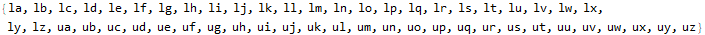

In [116]:
ShowIndices[Latin]

{{l0, u0}, {la, lb, lc, ld, le, lf, lg, lh, li, lj, lk, ll, lm, ln, lo, lp, lq, lr, ls, 
 
>    lt, lu, lv, lw, lx, ly, lz, ua, ub, uc, ud, ue, uf, ug, uh, ui, uj, uk, ul, um, un, 
 
>    uo, up, uq, ur, us, ut, uu, uv, uw, ux, uy, uz}}
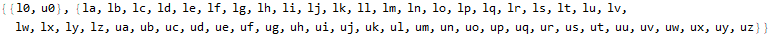

In [117]:
ShowIndices[All]

#### 2.2.2 SetIndices

프로그램에서 사용할 수 있는 `RegularType`의 인덱스들을 새로 정의한다. 첫 번째 인자는 사용할 문자 리스트이고, 옵션으로 두 번째 인자는 새로운 인덱스를 포함시킬 kind이다.

기본적으로 정의된 문자 리스트를 바꾸려면 SetIndices 명령을 사용한다:

In [118]:
SetIndices[{a, b, c, d}, Latin]; ShowIndices[Latin]

{la, lb, lc, ld, ua, ub, uc, ud}

In [119]:
ld = "NOT POSSIBLE";

Set::wrsym: Symbol ld is Protected.

Global`ld
DnIndexQ[ld] ^= True
mTensor`Private`indexKind[ld] ^= Latin


Attributes[ld]={Protected}
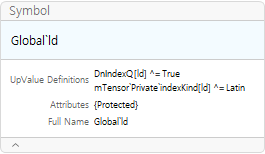

In [120]:
?ld

In [121]:
le = "POSSIBLE"

POSSIBLE

Global`le
le = "POSSIBLE"
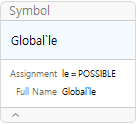

In [122]:
?le

In [123]:
SetIndices[{a, b, c, d, e}, Latin]; ShowIndices[Latin]

{la, lb, lc, ld, le, ua, ub, uc, ud, ue}

In [124]:
ld (* NB: Previous value of ld is CLEARED! *)

ld

In [125]:
le = "NOT POSSIBLE";

Set::wrsym: Symbol le is Protected.

Global`le
DnIndexQ[le] ^= True
mTensor`Private`indexKind[le] ^= Latin


Attributes[le]={Protected}
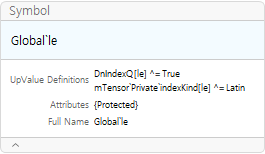

In [126]:
?le

기본적으로 정의된 문자 리스트를 제거하려면 `SetIndices` 명령의 첫 번째 인자로 빈 리스트 {}를 사용한다:

In [127]:
SetIndices[{}, Latin]; ShowIndices[Latin]

{}

In [128]:
la = "POSSIBLE"

POSSIBLE

Global`la
la = "POSSIBLE"
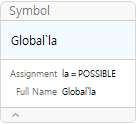

In [129]:
?la

In [130]:
SetIndices[{a, b}, Latin]; ShowIndices[Latin]

{la, lb, ua, ub}

In [131]:
ld (* NB: The previous value of ld is CLEARED! *)

ld

In [132]:
la = "NOT POSSIBLE";

Set::wrsym: Symbol la is Protected.

Global`la
DnIndexQ[la] ^= True
mTensor`Private`indexKind[la] ^= Latin


Attributes[la]={Protected}
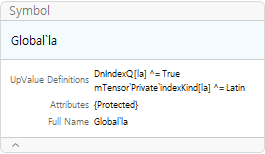

In [133]:
?la

In [134]:
DefineKind[{\[Mu], \[Nu], \[Rho], \[Sigma]}, Greek];
ShowIndices[Greek]

{lμ, lν, lρ, lσ, uμ, uν, uρ, uσ}

In [136]:
l\[Alpha] = "POSSIBLE"

POSSIBLE

In [137]:
l\[Mu] = "IMPOSSIBLE"

Set::wrsym: Symbol lÎ¼ is Protected.

IMPOSSIBLE

Global`lμ
DnIndexQ[lμ] ^= True
mTensor`Private`indexKind[lμ] ^= Greek


Attributes[lμ]={Protected}
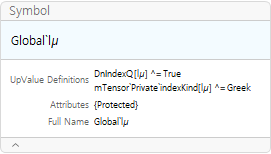

In [138]:
?l\[Mu]

{lα, lβ, lγ, lδ, lε, lζ, lη, lθ, lι, lκ, lλ, lμ, lν, lξ, lο, lπ, lρ, lσ, lτ, lυ, lφ, lχ, 
 
>   lψ, lω, uα, uβ, uγ, uδ, uε, uζ, uη, uθ, uι, uκ, uλ, uμ, uν, uξ, uο, uπ, uρ, uσ, uτ, 
 
>   uυ, uφ, uχ, uψ, uω}
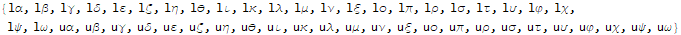

In [139]:
SetIndices[Alphabet["Greek"], Greek]; ShowIndices[Greek]

In [140]:
SetIndices[{a, \[Mu], c}, Greek]

`1` `2` `3` `4`: {a, Î¼, c} includes characters already defined as indices.  

In [141]:
RemoveKind[Greek]

In [142]:
SetIndices[{A, b, c}, Latin]; ShowIndices[Latin]  (* NO error! *)

{lA, lb, lc, uA, ub, uc}

{la, lb, lc, ld, le, lf, lg, lh, li, lj, lk, ll, lm, ln, lo, lp, lq, lr, ls, lt, lu, lv, 
 
>   lw, lx, ly, lz, ua, ub, uc, ud, ue, uf, ug, uh, ui, uj, uk, ul, um, un, uo, up, uq, 
 
>   ur, us, ut, uu, uv, uw, ux, uy, uz}
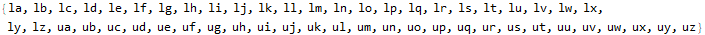

In [143]:
SetIndices[Alphabet[], Latin]; ShowIndices[Latin]  (* default *)

#### 2.2.3 AddIndices

프로그램에서 사용할 수 있는 `RegularType`의 인덱스들에 새로운 인덱스들을 포함시킨다. `SetIndices` 명령에 의해 정의된 인덱스들에 더해서 새로운 인덱스들을 포함시키려면 첫 번째 인자는 더해질 문자 리스트이고, 옵션으로 두 번째 인자는 인덱스가 속한 Kind이다.

In [144]:
DefineKind[{A, B}, Capital]; ShowIndices[Capital]

{lA, lB, uA, uB}

In [145]:
SetIndices[{}, Capital]; ShowIndices[Capital]

{}

In [146]:
AddIndices[{A, B, C}, Capital]; ShowIndices[Capital]

{lA, lB, lC, uA, uB, uC}

In [147]:
AddIndices[{B, C, D}, Capital]; ShowIndices[Capital]

`1` `2` `3` `4`: {B, C, D} includes characters already defined as indices.  

{lA, lB, lC, uA, uB, uC}

In [148]:
AddIndices[{D}, Capital]; ShowIndices[Capital]

{lA, lB, lC, lD, uA, uB, uC, uD}

Global`lB
DnIndexQ[lB] ^= True
mTensor`Private`indexKind[lB] ^= Capital


Attributes[lB]={Protected}
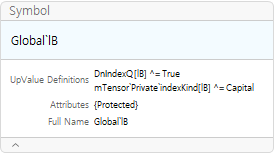

In [149]:
?lB

In [150]:
RemoveKind[Capital]

포함시킬 인덱스의 수가 많으면 첫 번째 인자로 포함시킬 인덱스의 수를 입력한다. 새로운 인덱스들은 프로그램 내부에서 문자와 일련번호를 조합하여 생성시킨다.

{la, lb, lc, ld, le, lf, lg, lh, li, lj, lk, ll, lm, ln, lo, lp, lq, lr, ls, lt, lu, lv, 
 
>   lw, lx, ly, lz, la1, ua, ub, uc, ud, ue, uf, ug, uh, ui, uj, uk, ul, um, un, uo, up, 
 
>   uq, ur, us, ut, uu, uv, uw, ux, uy, uz, ua1}
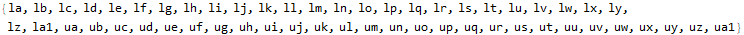

In [151]:
AddIndices[1, Latin]; ShowIndices[Latin]

Global`la1
DnIndexQ[la1] ^= True
mTensor`Private`indexKind[la1] ^= Latin


Attributes[la1]={Protected}
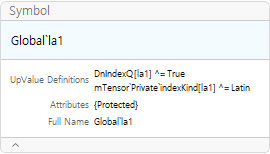

In [152]:
?la1

{la, lb, lc, ld, le, lf, lg, lh, li, lj, lk, ll, lm, ln, lo, lp, lq, lr, ls, lt, lu, lv, 
 
>   lw, lx, ly, lz, la1, la2, la3, la4, la5, la6, ua, ub, uc, ud, ue, uf, ug, uh, ui, 
 
>   uj, uk, ul, um, un, uo, up, uq, ur, us, ut, uu, uv, uw, ux, uy, uz, ua1, ua2, ua3, 
 
>   ua4, ua5, ua6}
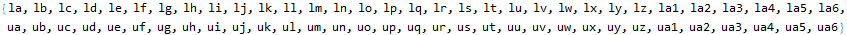

In [153]:
AddIndices[5, Latin]; ShowIndices[Latin]

{la, lb, lc, ld, le, lf, lg, lh, li, lj, lk, ll, lm, ln, lo, lp, lq, lr, ls, lt, lu, lv, 
 
>   lw, lx, ly, lz, la1, la2, la3, la4, la5, la6, la7, la8, la9, la10, la11, la12, la13, 
 
>   la14, la15, la16, la17, la18, la19, la20, la21, la22, la23, la24, la25, la26, la27, 
 
>   la28, la29, la30, la31, la32, la33, la34, la35, la36, la37, la38, la39, la40, la41, 
 
>   la42, la43, la44, la45, la46, la47, la48, la49, la50, la51, la52, la53, la54, la55, 
 
>   la56, la57, la58, la59, la60, la61, la62, la63, la64, la65, la66, la67, la68, la69, 
 
>   la70, la71, la72, la73, la74, la75, la76, la77, la78, la79, la80, la81, la82, la83, 
 
>   la84, la85, la86, la87, la88, la89, la90, la91, la92, la93, la94, la95, la96, la97, 
 
>   la98, la99, la100, la101, la102, la103, la104, la105, la106, la107, la108, la109, 
 
>   la110, la111, la112, la113, la114, la115, la116, la117, la118, la119, la120, la121, 
 
>   la122, la123, la124, la125, la126, la127, la128, la129, la130, la131, la132, la133, 
 
>   la134, la135, la136, la137, la138, la139, la140, la141, la142, la143, la144, la145, 
 
>   la146, la147, la148, la149, la150, la151, la152, la153, la154, la155, la156, la157, 
 
>   la158, la159, la160, la161, la162, la163, la164, la165, la166, la167, la168, la169, 
 
>   la170, la171, la172, la173, la174, la175, la176, la177, la178, la179, la180, la181, 
 
>   la182, la183, la184, la185, la186, la187, la188, la189, la190, la191, la192, la193, 
 
>   la194, la195, la196, la197, la198, la199, la200, la201, la202, la203, la204, la205, 
 
>   ua, ub, uc, ud, ue, uf, ug, uh, ui, uj, uk, ul, um, un, uo, up, uq, ur, us, ut, uu, 
 
>   uv, uw, ux, uy, uz, ua1, ua2, ua3, ua4, ua5, ua6, ua7, ua8, ua9, ua10, ua11, ua12, 
 
>   ua13, ua14, ua15, ua16, ua17, ua18, ua19, ua20, ua21, ua22, ua23, ua24, ua25, ua26, 
 
>   ua27, ua28, ua29, ua30, ua31, ua32, ua33, ua34, ua35, ua36, ua37, ua38, ua39, ua40, 
 
>   ua41, ua42, ua43, ua44, ua45, ua46, ua47, ua48, ua49, ua50, ua51, ua52, ua53, ua54, 
 
>   ua55, ua56, ua57, ua58, ua59, ua60, ua61, ua62, ua63, ua64, ua65, ua66, ua67, ua68, 
 
>   ua69, ua70, ua71, ua72, ua73, ua74, ua75, ua76, ua77, ua78, ua79, ua80, ua81, ua82, 
 
>   ua83, ua84, ua85, ua86, ua87, ua88, ua89, ua90, ua91, ua92, ua93, ua94, ua95, ua96, 
 
>   ua97, ua98, ua99, ua100, ua101, ua102, ua103, ua104, ua105, ua106, ua107, ua108, 
 
>   ua109, ua110, ua111, ua112, ua113, ua114, ua115, ua116, ua117, ua118, ua119, ua120, 
 
>   ua121, ua122, ua123, ua124, ua125, ua126, ua127, ua128, ua129, ua130, ua131, ua132, 
 
>   ua133, ua134, ua135, ua136, ua137, ua138, ua139, ua140, ua141, ua142, ua143, ua144, 
 
>   ua145, ua146, ua147, ua148, ua149, ua150, ua151, ua152, ua153, ua154, ua155, ua156, 
 
>   ua157, ua158, ua159, ua160, ua161, ua162, ua163, ua164, ua165, ua166, ua167, ua168, 
 
>   ua169, ua170, ua171, ua172, ua173, ua174, ua175, ua176, ua177, ua178, ua179, ua180, 
 
>   ua181, ua182, ua183, ua184, ua185, ua186, ua187, ua188, ua189, ua190, ua191, ua192, 
 
>   ua193, ua194, ua195, ua196, ua197, ua198, ua199, ua200, ua201, ua202, ua203, ua204, 
 
>   ua205}
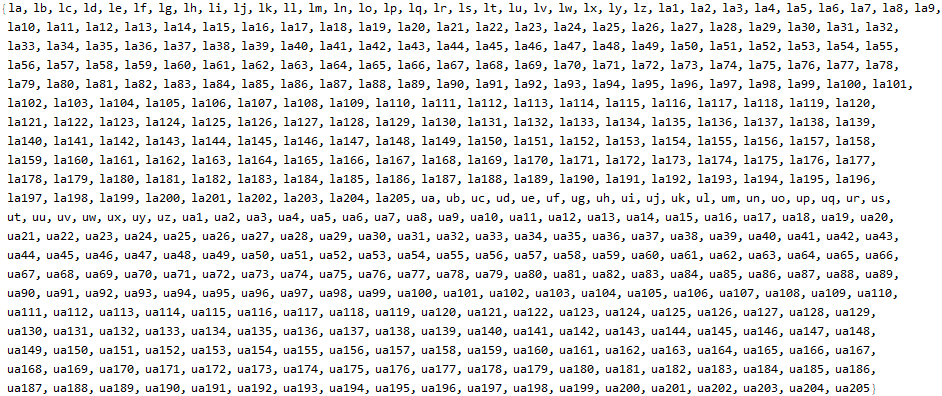

In [154]:
AddIndices[100, Latin]; AddIndices[99, Latin];
ShowIndices[Latin]

Global`ua205
UpIndexQ[ua205] ^= True
mTensor`Private`indexKind[ua205] ^= Latin


Attributes[ua205]={Protected}
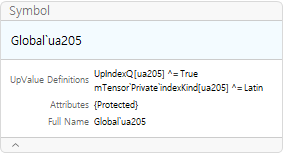

In [155]:
?ua205

{la, lb, lc, ld, le, lf, lg, lh, li, lj, lk, ll, lm, ln, lo, lp, lq, lr, ls, lt, lu, lv, 
 
>   lw, lx, ly, lz, ua, ub, uc, ud, ue, uf, ug, uh, ui, uj, uk, ul, um, un, uo, up, uq, 
 
>   ur, us, ut, uu, uv, uw, ux, uy, uz}
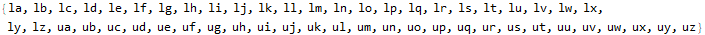

In [156]:
SetIndices[Alphabet[], Latin]; ShowIndices[Latin]  (* default *)

In [157]:
DefineKind[{\[Mu]}, Greek]

In [158]:
AddIndices[2, Greek]; ShowIndices[Greek]

{lμ, lμ1, lμ2, uμ, uμ1, uμ2}

Global`uμ1
UpIndexQ[uμ1] ^= True
mTensor`Private`indexKind[uμ1] ^= Greek


Attributes[uμ1]={Protected}
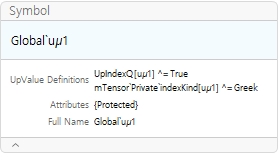

In [159]:
?u\[Mu]1

In [160]:
RemoveKind[Greek]

In [161]:
DefineKind[{A}, Capital]

In [162]:
AddIndices[3, Capital]; ShowIndices[Capital]

{lA, lA1, lA2, lA3, uA, uA1, uA2, uA3}

Global`lA3
DnIndexQ[lA3] ^= True
mTensor`Private`indexKind[lA3] ^= Capital


Attributes[lA3]={Protected}
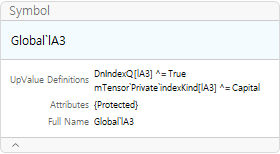

In [163]:
?lA3

In [164]:
SetIndices[{A, B}, Capital]; ShowIndices[Capital]

{lA, lB, uA, uB}

Global`lA3
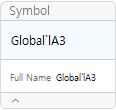

In [165]:
?lA3

In [166]:
AddIndices[4, Capital]; ShowIndices[Capital]

{lA, lB, lA4, lA5, lA6, lA7, uA, uB, uA4, uA5, uA6, uA7}

Global`lA4
DnIndexQ[lA4] ^= True
mTensor`Private`indexKind[lA4] ^= Capital


Attributes[lA4]={Protected}
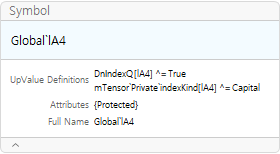

In [167]:
?lA4

In [168]:
RemoveKind[Capital]

In [169]:
DefineKind["b" <> # & /@ Alphabet[], Bar]

{lba, lbb, lbc, lbd, lbe, lbf, lbg, lbh, lbi, lbj, lbk, lbl, lbm, lbn, lbo, lbp, lbq, 
 
>   lbr, lbs, lbt, lbu, lbv, lbw, lbx, lby, lbz, lba1, lba2, lba3, lba4, uba, ubb, ubc, 
 
>   ubd, ube, ubf, ubg, ubh, ubi, ubj, ubk, ubl, ubm, ubn, ubo, ubp, ubq, ubr, ubs, ubt, 
 
>   ubu, ubv, ubw, ubx, uby, ubz, uba1, uba2, uba3, uba4}
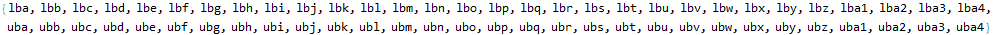

In [170]:
AddIndices[4, Bar]; ShowIndices[Bar]

In [171]:
RemoveKind[Bar]

In [172]:
DefineKind[{da}, Dot]

In [173]:
AddIndices[5, Dot]; ShowIndices[Dot]

{lda, lda1, lda2, lda3, lda4, lda5, uda, uda1, uda2, uda3, uda4, uda5}

In [174]:
RemoveKind[Dot]

In [175]:
DefineKind[{ha}, Hat]

In [176]:
AddIndices[6, Hat]; ShowIndices[Hat]

{lha, lha1, lha2, lha3, lha4, lha5, lha6, uha, uha1, uha2, uha3, uha4, uha5, uha6}

In [177]:
RemoveKind[Hat]

## 3. 인덱스 함수

In [178]:
DefineKind[Alphabet["Greek"], Greek];
DefineKind[ToUpperCase /@ Alphabet[], Capital];
DefineKind["b" <> # & /@ Alphabet[], Bar];
DefineKind["d" <> # & /@ Alphabet[], Dot];
DefineKind["h" <> # & /@ Alphabet[], Hat];

### 3.1 Dummy

프로그램에 의해 생성되는 dummy 인덱스를 돌려 준다. 결과값은 프로그램 동작 중 유일하고 dn 형태이다. 인자는 Kind이다.

In [183]:
TMP`definedKindList

{Zero, Latin, Greek, Capital, Bar, Dot, Hat}

In [184]:
TMP`dummyPreCharacter[#] & /@ TMP`definedKindList

{/, $, ;, ?, %, !, @}

In [185]:
TMP`dummyState[#] & /@ TMP`definedKindList

{1, 1, 1, 1, 1, 1, 1}

In [186]:
Dummy /@ TMP`definedKindList

{l/1, l$1, l;1, l?1, l%1, l!1, l@1}

### 3.2 DummyPair

프로그램에 의해 생성되는 dummy 인덱스의 쌍을 리스트로 돌려 준다. 결과값은 유일하고 {dn, up} 형태이다. 인자는 Kind이다.

In [187]:
DummyPair /@ TMP`definedKindList

{{l/2, u/2}, {l$2, u$2}, {l;2, u;2}, {l?2, u?2}, {l%2, u%2}, {l!2, u!2}, {l@2, u@2}}

### 3.3 FlipIndex

인덱스의 dn과 up을 뒤바꾼다.

In [188]:
FlipIndex /@ dnIndexL

{1, u0, ua, uA, uba, uda, uha}

In [189]:
FlipIndex /@ %

{-1, l0, la, lA, lba, lda, lha}

In [190]:
FlipIndex /@ indexL

{1, u0, ua, uA, uba, uda, uha, -1, l0, la, lA, lba, lda, lha}

### 3.4 IndexOrderedQ, IndexSort

`IndexOrderedQ`는 인덱스가 순서대로 정렬되었는가를 판단하는 질의함수이다. 그리고 `IndexSort`는 주어진 인덱스를 순서대로 정렬하는 함수이다. 순서는 Regular/Dummy/Component, Free/Dummy, Lexicographic, Down/Up에 따른다.

In [191]:
idxL = {la, ua, lb, ub, "la", "ua", "lb", "ub", -1, 1};

In [192]:
dummyIndexSort = TMP`takePairs@idxL

{la, ua, lb, ub}

In [193]:
lexIndexSort = Union[ToUpIndex /@ idxL]

{1, ua, ub, ua, ub}

{{1.2, True, {{4}}, False, la}, {1.2, True, {{4}}, True, ua}, 
 
>   {1.2, True, {{5}}, False, lb}, {1.2, True, {{5}}, True, ub}, 
 
>   {3., False, {{2}}, False, la}, {3., False, {{2}}, True, ua}, 
 
>   {3., False, {{3}}, False, lb}, {3., False, {{3}}, True, ub}, 
 
>   {7, False, {{1}}, False, -1}, {7, False, {{1}}, True, 1}}
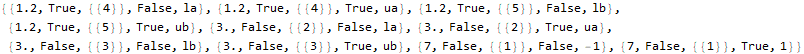

In [194]:
{TMP`typeIndexSort[#], MemberQ[dummyIndexSort, #],
 Position[lexIndexSort, ToUpIndex[#], {1}],
 UpIndexQ[#], #} & /@ idxL

{{1.2, True, {{4}}, False, la}, {1.2, True, {{4}}, True, ua}, 
 
>   {1.2, True, {{5}}, False, lb}, {1.2, True, {{5}}, True, ub}, 
 
>   {3., False, {{2}}, False, la}, {3., False, {{2}}, True, ua}, 
 
>   {3., False, {{3}}, False, lb}, {3., False, {{3}}, True, ub}, 
 
>   {7, False, {{1}}, False, -1}, {7, False, {{1}}, True, 1}}
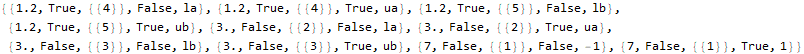

In [195]:
Sort[%]

In [196]:
Last /@ %

{la, ua, lb, ub, la, ua, lb, ub, -1, 1}

In [197]:
% == IndexSort[idxL]

True

In [198]:
Sort[idxL]

{-1, 1, la, lb, ua, ub, la, lb, ua, ub}

In [199]:
IndexOrderedQ[{lb, "la"}]

True

In [200]:
IndexSort[{lb, "la"}]

{lb, la}

In [201]:
IndexOrderedQ[{la, lb}]

True

In [202]:
IndexSort[{la, lb}]

{la, lb}

In [203]:
IndexOrderedQ[{la, ua}]

True

In [204]:
IndexSort[{la, ua}]

{la, ua}

In [205]:
IndexOrderedQ[{la, ua, lb, ub, "la", "ua", "lb", "ub", -1, 1}]

True

In [206]:
IndexSort[{la, ua, lb, ub, "la", "ua", "lb", "ub", -1, 1}]

{la, ua, lb, ub, la, ua, lb, ub, -1, 1}

In [207]:
IndexOrderedQ[{"l$2", "l$1"}]

False

In [208]:
IndexSort[{"l$2", "l$1"}]

{l$1, l$2}

In [209]:
IndexOrderedQ[{la, lb}, {la, lc}]

True

### 3.5 PairIndexQ

인자의 인덱스들이 dn/up 쌍인가에 대한 질의함수이다. 인자는 두 개의 인덱스이거나 {a,b} 형태인 임의의 갯수의 인덱스 리스트들이다.

In [210]:
{PairIndexQ[la, ua], PairIndexQ[la, ub], PairIndexQ[-1, 1], 
 PairIndexQ[la, la], PairIndexQ[l0, u0]}

{True, False, False, False, False}

In [211]:
{PairIndexQ[uA, lA], PairIndexQ[lA, uB], PairIndexQ[lA, lA]}

{True, False, False}

In [212]:
PairIndexQ[{la, ua}, {l\[Mu], u\[Mu]}, {lA, uA}]

True

### 3.6 TakePairs

인자로 주어진 인덱스 리스트에서 dn과 up으로 쌍을 이루는 인덱스들을 돌려 준다. 결과값은 {{dn,up},...} 형태이다. 옵션으로 `IndexQs`를 갖는다.

In [213]:
indexL

{-1, l0, la, lA, lba, lda, lha, 1, u0, ua, uA, uba, uda, uha}

In [214]:
TMP`takePairs[indexL]

{la, lA, lba, lda, lha, ua, uA, uba, uda, uha}

In [215]:
ToDnIndex /@ %

{la, lA, lba, lda, lha, la, lA, lba, lda, lha}

In [216]:
Union@%

{la, lA, lba, lda, lha}

In [217]:
{#, ToUpIndex[#]} & /@ %

{{la, ua}, {lA, uA}, {lba, uba}, {lda, uda}, {lha, uha}}

In [218]:
% == TakePairs[indexL]

True

In [219]:
TakePairs[indexL, IndexQs -> {KindIndexQ[Latin]}]

{{la, ua}}

### 3.7 TensorialIndexQ

기호 텐서에 대한 인덱스인가에 대한 질의함수이다. 인덱스가 `ComponentIndexQ`를 만족하지 않으면 텐서 인덱스이다.

In [220]:
TMP`indexKind /@ dnIndexL

{ComponentIndexQ, Zero, Latin, Capital, Bar, Dot, Hat}

In [221]:
TensorialIndexQ /@ dnIndexL

{False, True, True, True, True, True, True}

In [222]:
TensorialIndexQ[#] && KindIndexQ[Greek][#] & /@ dnIndexL

{False, False, False, False, False, False, False}

In [223]:
Select[indexL, TensorialIndexQ]

{l0, la, lA, lba, lda, lha, u0, ua, uA, uba, uda, uha}

### 3.8 ToDnIndex

인덱스가 up이면 dn으로 바꾼다.

In [224]:
ToDnIndex /@ upIndexL

{-1, l0, la, lA, lba, lda, lha}

In [225]:
ToDnIndex /@ indexL

{-1, l0, la, lA, lba, lda, lha, -1, l0, la, lA, lba, lda, lha}

### 3.9 ToUpIndex

인덱스가 dn이면 up으로 바꾼다.

In [226]:
ToUpIndex /@ dnIndexL

{1, u0, ua, uA, uba, uda, uha}

In [227]:
ToUpIndex /@ indexL

{1, u0, ua, uA, uba, uda, uha, 1, u0, ua, uA, uba, uda, uha}

### 3.10 Private utils

In [228]:
indexL

{-1, l0, la, lA, lba, lda, lha, 1, u0, ua, uA, uba, uda, uha}

#### 3.10.1 dnupState

In [229]:
TMP`dnupState /@ indexL

{-1, -1, -1, -1, -1, -1, -1, 1, 1, 1, 1, 1, 1, 1}

#### 3.10.2 takeFrees

In [230]:
TMP`takeFrees[{la, ua, lc}]

{lc}

#### 3.10.3 dropPairs, takePairs, takePairsProper

In [231]:
TMP`dropPairs[indexL]

{-1, l0, 1, u0}

In [232]:
TMP`takePairs[indexL]

{la, lA, lba, lda, lha, ua, uA, uba, uda, uha}

In [233]:
TMP`takePairsProper[indexL]

{{la, ua}, {lA, uA}, {lba, uba}, {lda, uda}, {lha, uha}}

#### 3.10.4 inPairQ

In [235]:
TMP`inPairQ[indexL, #] & /@ indexL

{False, False, True, True, True, True, True, False, False, True, True, True, True, True}

#### 3.10.5 upupdndnIndexQ

In [236]:
TMP`upupdndnIndexQ /@ {{la, lb, lc}, {la, ub, lc},
                         {ua, ub, lc}, {ua, ub, ua}}

{True, False, False, True}

### 3.11 디폴트로 복귀

In [237]:
RemoveKind /@ {Greek, Capital, Bar, Dot, Hat};

In [238]:
TMP`definedKindList

{Zero, Latin}

## 4. Checking Indices

In [239]:
DefineKind[Alphabet["Greek"], Greek];
DefineKind[ToUpperCase /@ Alphabet[], Capital];
DefineKind["b" <> # & /@ Alphabet[], Bar];
DefineKind["d" <> # & /@ Alphabet[], Dot];
DefineKind["h" <> # & /@ Alphabet[], Hat];

### 4.1 ValidIndexQ

인자가 텐서 인덱스(들)로서 합당한가를 판단하는 질의함수이다. 성분 인덱스도 합당한 인덱스로 간주한다.

In [244]:
indexL

{-1, l0, la, lA, lba, lda, lha, 1, u0, ua, uA, uba, uda, uha}

In [245]:
DefaultKind

Latin

In [246]:
ValidIndexQ /@ indexL  (* DefaultKind *)

{True, False, True, False, False, False, False, True, False, True, False, False, False, 
 
>   False}

In [247]:
SetIndices[{\[Mu], \[Nu]}, Greek]; SetIndices[{A, B}, Capital];

In [248]:
ValidIndexQ[#, All] & /@ indexL

{True, True, True, True, True, True, True, True, True, True, True, True, True, True}

In [249]:
ValidIndexQ[indexL]  (* are all of indexL valid? *)

False

In [250]:
Select[indexL, ValidIndexQ[#] && TensorialIndexQ[#] &]

{la, ua}

옵션으로 kind가 주어지면 그 kind에 합당한 인덱스인가를 판단한다. Kind가 옵션으로 주어지지 않은 경우는 kind == `DefaultKind`와 같다.

In [251]:
Select[indexL, ValidIndexQ]

{-1, la, 1, ua}

In [252]:
SetIndices[{ba, bb}, Bar]; SetIndices[{ha, hb}, Hat]

In [253]:
Select[indexL, ValidIndexQ[#, All] &]

{-1, l0, la, lA, lba, lda, lha, 1, u0, ua, uA, uba, uda, uha}

In [254]:
Select[indexL, ValidIndexQ[#, OtherKind] &]

{-1, 1}

### 4.2 ValidIndicesQ

인자 리스트의 인덱스들 모두가 서로 합당한가를 판단하는 질의함수이다.

In [255]:
ValidIndicesQ[{1, la}]

True

옵션으로 kind가 주어지면 모든 인덱스가 그 kind와 합당한가를 확인한다.

In [256]:
ValidIndicesQ[{la, l\[Mu]}, Latin]

False

In [257]:
SetIndices[{\[Mu], \[Nu], \[Rho], \[Sigma]}, Greek]

In [258]:
ValidIndicesQ[{la, l\[Mu]}, All]

True

동일한 인덱스가 있으면 합당하지 않은 것으로 간주한다:

In [259]:
{ValidIndicesQ[{la, ua}], ValidIndicesQ[{la, la}]}

{True, False}

### 4.3 duplicatedIndicesQ

In [260]:
TMP`duplicatedIndicesQ[{la, lb, ua, la}]

True

In [261]:
TMP`duplicatedIndicesQ[{la, lb, ua, la}, True]

`1` `2` `3` `4`: duplicated indices: {la, lb, ua, la}  

True

### 4.4 디폴트로 복귀

In [262]:
RemoveKind /@ {Greek, Capital, Bar, Dot, Hat};